# PHX at OKC One-Game Study

This notebook compares model-implied live **OKC win probability** against the Kalshi minute-level market price path for the April 22, 2026 Suns at Thunder playoff game.

Updated workflow:
1. Load the pooled historical scoring distribution.
2. Use the **pregame Kalshi yes price** and the market total to infer pregame lambdas.
3. Load the Kalshi minute price history and NBA scoring-event path.
4. Align score state to each Kalshi timestamp.
5. Reprice live with two variants:
   - fixed pregame market-implied lambdas
   - dynamically updated lambdas with pace and team-share shrinkage
6. Plot the model path against Kalshi and summarize the gap.

This is a **forecast comparison** study, not an executable bid/ask trading backtest.

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == "scripts":
    project_root = project_root.parent
elif not ((project_root / "src").exists() and (project_root / "data").exists()):
    project_root = Path("/Users/hankrugg/Fordham/Spring26/SimApp/Project")

sys.path.insert(0, str(project_root / "src"))

from Backtest import build_score_state_grid
from Calibration import Calibration, load_distribution, imply_intensities_from_spread_total
from MonteCarlo import price_from_state, update_total_pace

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
project_root

PosixPath('/Users/hankrugg/Fordham/Spring26/SimApp/Project')

In [10]:
TEAM_A = "OKC"
TEAM_B = "PHX"
TEAM_A_NAME = "Oklahoma City"
TEAM_B_NAME = "Phoenix"
HORIZON_MINUTES = 48.0

MARKET_TOTAL_POINTS = 215.0
REFERENCE_SPREAD_TEAM_A_MINUS_TEAM_B = 17.0

PRIOR_WEIGHT_MINUTES = 12.0
PRIOR_WEIGHT_EVENTS = 35.0
CALIBRATION_SIMULATIONS = 20_000
CALIBRATION_GRID_SIZE = 31
NUM_SIMULATIONS = 10_000
SEED = 42

distribution_path = project_root / "data" / "processed" / "scoring_distribution_2024-25_regular_season.csv"
kalshi_path = project_root / "data" / "processed" / "kalshi" / "kalshi-price-history-kxnbagame-26apr22phxokc-minute.csv"
score_path = project_root / "data" / "processed" / "nba" / "score_path_0042500142_okc_phx.csv"

distribution_path, kalshi_path, score_path

(PosixPath('/Users/hankrugg/Fordham/Spring26/SimApp/Project/data/processed/scoring_distribution_2024-25_regular_season.csv'),
 PosixPath('/Users/hankrugg/Fordham/Spring26/SimApp/Project/data/processed/kalshi/kalshi-price-history-kxnbagame-26apr22phxokc-minute.csv'),
 PosixPath('/Users/hankrugg/Fordham/Spring26/SimApp/Project/data/processed/nba/score_path_0042500142_okc_phx.csv'))

In [11]:
distribution, p = load_distribution(distribution_path)

kalshi = pd.read_csv(kalshi_path)
kalshi["timestamp"] = pd.to_datetime(kalshi["timestamp"], utc=True)
kalshi = kalshi.rename(
    columns={
        TEAM_A_NAME: "kalshi_yes_price_cents",
        TEAM_B_NAME: "kalshi_no_price_cents",
    }
)
kalshi["kalshi_yes_price"] = kalshi["kalshi_yes_price_cents"] / 100.0
kalshi = kalshi.dropna(subset=["kalshi_yes_price"]).sort_values("timestamp").reset_index(drop=True)

score = pd.read_csv(score_path)
score["timestamp"] = pd.to_datetime(score["timestamp"], utc=True, format="mixed")
score = score.sort_values("timestamp").reset_index(drop=True)

score["delta_a"] = score["score_a"].diff().fillna(score["score_a"]).clip(lower=0)
score["delta_b"] = score["score_b"].diff().fillna(score["score_b"]).clip(lower=0)
score["event_a"] = (score["delta_a"] > 0).astype(int)
score["event_b"] = (score["delta_b"] > 0).astype(int)
score["scoring_events_a"] = score["event_a"].cumsum()
score["scoring_events_b"] = score["event_b"].cumsum()

game_start = score["timestamp"].min() - pd.Timedelta(minutes=1)
game_end = score["timestamp"].max() + pd.Timedelta(minutes=1)

kalshi_pregame = kalshi.loc[kalshi["timestamp"] < game_start].copy().tail(1)
if kalshi_pregame.empty:
    kalshi_pregame = kalshi.head(1).copy()

kalshi_live = kalshi.loc[kalshi["timestamp"].between(game_start, game_end)].copy()
kalshi_live = kalshi_live[["timestamp", "kalshi_yes_price"]].reset_index(drop=True)
market_yes_prob_0 = float(kalshi_pregame["kalshi_yes_price"].iloc[0])

print(f"Pregame Kalshi yes probability used for calibration: {market_yes_prob_0:.4f}")
print(f"Kalshi rows during game window: {len(kalshi_live)}")
print(f"Scoring-event rows: {len(score)}")

display(distribution)
display(kalshi_pregame[["timestamp", "kalshi_yes_price"]])
display(kalshi_live.head())
display(score.head())

Pregame Kalshi yes probability used for calibration: 0.9137
Kalshi rows during game window: 148
Scoring-event rows: 120


,season,season_type,points_scored,score_type,count,percentage
0,2024-25,Regular Season,1,free_throw,41574,0.288428
1,2024-25,Regular Season,2,two_pointer,69262,0.480519
2,2024-25,Regular Season,3,three_pointer,33304,0.231053


,timestamp,kalshi_yes_price
3374,2026-04-23 01:47:00+00:00,0.9137


,timestamp,kalshi_yes_price
0,2026-04-23 01:48:00+00:00,0.9198
1,2026-04-23 01:49:00+00:00,0.9199
2,2026-04-23 01:50:00+00:00,0.9103
3,2026-04-23 01:51:00+00:00,0.9170
4,2026-04-23 01:52:00+00:00,0.9045


,game_id,timestamp,elapsed_minutes,score_a,score_b,total_scoring_events,current_margin,team_a_abbrev,team_b_abbrev,period,clock,timeActual,actionType,description,delta_a,delta_b,event_a,event_b,scoring_events_a,scoring_events_b
0,42500142,2026-04-23 01:48:39.700000+00:00,0.600000,0,2,1,-2,OKC,PHX,1,PT11M24.00S,2026-04-23T01:48:39.7Z,2pt,C. Gillespie 8' step back Jump Shot (2 PTS) (D...,0.0,2.0,0,1,0,1
1,42500142,2026-04-23 01:48:57.400000+00:00,0.900000,3,2,2,1,OKC,PHX,1,PT11M06.00S,2026-04-23T01:48:57.4Z,3pt,L. Dort 25' 3PT (3 PTS) (S. Gilgeous-Alexande...,3.0,0.0,1,0,1,1
2,42500142,2026-04-23 01:49:19+00:00,1.266667,3,4,3,-1,OKC,PHX,1,PT10M44.00S,2026-04-23T01:49:19.0Z,2pt,D. Brooks 10' pullup Jump Shot (2 PTS) (C. Gil...,0.0,2.0,0,1,1,2
3,42500142,2026-04-23 01:49:56.600000+00:00,1.883333,6,4,4,2,OKC,PHX,1,PT10M07.00S,2026-04-23T01:49:56.6Z,3pt,C. Holmgren 3PT (3 PTS) (I. Hartenstein 1 AST),3.0,0.0,1,0,2,2
4,42500142,2026-04-23 01:50:37.900000+00:00,2.566667,6,6,5,0,OKC,PHX,1,PT09M26.00S,2026-04-23T01:50:37.9Z,2pt,J. Green running Layup (2 PTS) (C. Gillespie 2...,0.0,2.0,0,1,2,3


In [12]:
spread_implied = pd.Series(
    imply_intensities_from_spread_total(
        p=p,
        horizon=HORIZON_MINUTES,
        market_total_points=MARKET_TOTAL_POINTS,
        market_team_a_minus_team_b_spread=REFERENCE_SPREAD_TEAM_A_MINUS_TEAM_B,
        team_a=TEAM_A,
        team_b=TEAM_B,
    )
)

market_calibration = Calibration(
    p=p,
    horizon=HORIZON_MINUTES,
    market_yes_prob=market_yes_prob_0,
    market_total_points=MARKET_TOTAL_POINTS,
    num_simulations=CALIBRATION_SIMULATIONS,
    seed=SEED,
)
kalshi_total_fit = pd.Series(
    market_calibration.calibrate(num_grid=CALIBRATION_GRID_SIZE)
)
kalshi_total_fit["market_yes_prob_0"] = market_yes_prob_0
kalshi_total_fit["pregame_quote_timestamp"] = kalshi_pregame["timestamp"].iloc[0]

comparison = pd.DataFrame(
    {
        "spread_plus_total": {
            "lambda_a": spread_implied["lambda_a_0"],
            "lambda_b": spread_implied["lambda_b_0"],
            "lambda_total": spread_implied["lambda_total_0"],
            "strength_share_a": spread_implied["strength_share_a_0"],
        },
        "kalshi_yes_plus_total": {
            "lambda_a": kalshi_total_fit["lambda_a_hat"],
            "lambda_b": kalshi_total_fit["lambda_b_hat"],
            "lambda_total": kalshi_total_fit["lambda_sum"],
            "strength_share_a": kalshi_total_fit["lambda_a_hat"] / kalshi_total_fit["lambda_sum"],
        },
    }
)

display(kalshi_total_fit.to_frame(name="value"))
display(comparison)

,value
lambda_sum,2.305729
lambda_a_hat,1.315465
lambda_b_hat,0.990264
expected_points_per_event,1.942625
model_yes_prob,0.9139
model_yes_ci_low,0.910012
model_yes_ci_high,0.917788
solve_status,Root found with brentq on the scanned bracket.
market_yes_prob_0,0.9137
pregame_quote_timestamp,2026-04-23 01:47:00+00:00


,spread_plus_total,kalshi_yes_plus_total
lambda_a,1.244021,1.315465
lambda_b,1.061708,0.990264
lambda_total,2.305729,2.305729
strength_share_a,0.539535,0.570520


In [13]:
score_state_grid = build_score_state_grid(score, kalshi_live["timestamp"])

team_event_state = pd.merge_asof(
    kalshi_live[["timestamp"]].sort_values("timestamp"),
    score[["timestamp", "scoring_events_a", "scoring_events_b"]]
        .sort_values("timestamp")
        .groupby("timestamp", as_index=False)
        .last(),
    on="timestamp",
    direction="backward",
)
team_event_state[["scoring_events_a", "scoring_events_b"]] = team_event_state[["scoring_events_a", "scoring_events_b"]].fillna(0).astype(int)

analysis = kalshi_live.merge(score_state_grid, on="timestamp", how="left", validate="one_to_one")
analysis = analysis.merge(team_event_state, on="timestamp", how="left", validate="one_to_one")
analysis["time_remaining"] = np.maximum(HORIZON_MINUTES - analysis["elapsed_minutes"], 0.0)
analysis["timestamp_et"] = analysis["timestamp"].dt.tz_convert("America/New_York")

analysis[[
    "timestamp_et",
    "kalshi_yes_price",
    "elapsed_minutes",
    "score_a",
    "score_b",
    "current_margin",
    "time_remaining",
    "total_scoring_events",
    "scoring_events_a",
    "scoring_events_b",
]].head(10)

,timestamp_et,kalshi_yes_price,elapsed_minutes,score_a,score_b,current_margin,time_remaining,total_scoring_events,scoring_events_a,scoring_events_b
0,2026-04-22 21:48:00-04:00,0.9198,0.000000,0,0,0,48.000000,0,0,0
1,2026-04-22 21:49:00-04:00,0.9199,0.900000,3,2,1,47.100000,2,1,1
2,2026-04-22 21:50:00-04:00,0.9103,1.883333,6,4,2,46.116667,4,2,2
3,2026-04-22 21:51:00-04:00,0.9170,2.566667,6,6,0,45.433333,5,2,3
4,2026-04-22 21:52:00-04:00,0.9045,3.266667,6,9,-3,44.733333,6,2,4
5,2026-04-22 21:53:00-04:00,0.8898,3.783333,10,9,1,44.216667,9,5,4
6,2026-04-22 21:54:00-04:00,0.8888,4.783333,15,14,1,43.216667,13,7,6
7,2026-04-22 21:55:00-04:00,0.9030,5.616667,17,14,3,42.383333,14,8,6
8,2026-04-22 21:56:00-04:00,0.9084,5.616667,17,14,3,42.383333,14,8,6
9,2026-04-22 21:57:00-04:00,0.9099,5.616667,17,14,3,42.383333,14,8,6


In [14]:
lambda_a_0 = float(kalshi_total_fit["lambda_a_hat"])
lambda_b_0 = float(kalshi_total_fit["lambda_b_hat"])
lambda_total_0 = float(kalshi_total_fit["lambda_sum"])
strength_share_a_0 = lambda_a_0 / lambda_total_0


def update_strength_share(strength_share_0, scoring_events_a, scoring_events_b, prior_weight_events=35.0):
    total_events = float(scoring_events_a) + float(scoring_events_b)
    if total_events <= 0.0:
        return float(strength_share_0)
    return (
        float(prior_weight_events) * float(strength_share_0) + float(scoring_events_a)
    ) / (float(prior_weight_events) + total_events)


def compute_live_model_path(base_df, use_dynamic_updates):
    rows = []

    for idx, row in enumerate(base_df.itertuples(index=False), start=1):
        if use_dynamic_updates:
            lambda_total_t = update_total_pace(
                lambda_total_0=lambda_total_0,
                elapsed_minutes=row.elapsed_minutes,
                total_scoring_events_observed=row.total_scoring_events,
                prior_weight_minutes=PRIOR_WEIGHT_MINUTES,
            )
            strength_share_t = update_strength_share(
                strength_share_0=strength_share_a_0,
                scoring_events_a=row.scoring_events_a,
                scoring_events_b=row.scoring_events_b,
                prior_weight_events=PRIOR_WEIGHT_EVENTS,
            )
            lambda_a_t = strength_share_t * lambda_total_t
            lambda_b_t = (1.0 - strength_share_t) * lambda_total_t
        else:
            lambda_total_t = lambda_total_0
            strength_share_t = strength_share_a_0
            lambda_a_t = lambda_a_0
            lambda_b_t = lambda_b_0

        pricing = price_from_state(
            current_margin=row.current_margin,
            time_remaining=row.time_remaining,
            lambda_a=lambda_a_t,
            lambda_b=lambda_b_t,
            p=p,
            num_simulations=NUM_SIMULATIONS,
            seed=SEED + idx,
        )

        rows.append(
            {
                "timestamp": row.timestamp,
                "fair_yes": pricing["price"],
                "se": pricing["standard_error"],
                "ci_low": pricing["confidence_interval"][0],
                "ci_high": pricing["confidence_interval"][1],
                "lambda_total_t": lambda_total_t,
                "strength_share_t": strength_share_t,
                "lambda_a_t": lambda_a_t,
                "lambda_b_t": lambda_b_t,
            }
        )

    return pd.DataFrame(rows)


fixed_path = compute_live_model_path(analysis, use_dynamic_updates=False).add_prefix("fixed_")
fixed_path = fixed_path.rename(columns={"fixed_timestamp": "timestamp"})

dynamic_path = compute_live_model_path(analysis, use_dynamic_updates=True).add_prefix("dynamic_")
dynamic_path = dynamic_path.rename(columns={"dynamic_timestamp": "timestamp"})

analysis = analysis.merge(fixed_path, on="timestamp", how="left", validate="one_to_one")
analysis = analysis.merge(dynamic_path, on="timestamp", how="left", validate="one_to_one")

analysis["fixed_gap"] = analysis["fixed_fair_yes"] - analysis["kalshi_yes_price"]
analysis["dynamic_gap"] = analysis["dynamic_fair_yes"] - analysis["kalshi_yes_price"]

analysis[[
    "timestamp_et",
    "score_a",
    "score_b",
    "current_margin",
    "kalshi_yes_price",
    "fixed_fair_yes",
    "dynamic_fair_yes",
    "fixed_gap",
    "dynamic_gap",
    "dynamic_lambda_total_t",
    "dynamic_strength_share_t",
]].head(10)

,timestamp_et,score_a,score_b,current_margin,kalshi_yes_price,fixed_fair_yes,dynamic_fair_yes,fixed_gap,dynamic_gap,dynamic_lambda_total_t,dynamic_strength_share_t
0,2026-04-22 21:48:00-04:00,0,0,0,0.9198,0.9222,0.9222,0.0024,0.0024,2.305729,0.570520
1,2026-04-22 21:49:00-04:00,3,2,1,0.9199,0.9229,0.9090,0.0030,-0.0109,2.299903,0.566708
2,2026-04-22 21:50:00-04:00,6,4,2,0.9103,0.9244,0.9048,0.0141,-0.0055,2.281062,0.563287
3,2026-04-22 21:51:00-04:00,6,6,0,0.9170,0.9078,0.8229,-0.0092,-0.0941,2.242706,0.549205
4,2026-04-22 21:52:00-04:00,6,9,-3,0.9045,0.8784,0.6888,-0.0261,-0.2157,2.205376,0.535810
5,2026-04-22 21:53:00-04:00,10,9,1,0.8898,0.9141,0.9068,0.0243,0.0170,2.323257,0.567459
6,2026-04-22 21:54:00-04:00,15,14,1,0.8888,0.9084,0.8843,0.0196,-0.0045,2.423163,0.561838
7,2026-04-22 21:55:00-04:00,17,14,3,0.9030,0.9270,0.9283,0.0240,0.0253,2.365302,0.570780
8,2026-04-22 21:56:00-04:00,17,14,3,0.9084,0.9250,0.9293,0.0166,0.0209,2.365302,0.570780
9,2026-04-22 21:57:00-04:00,17,14,3,0.9099,0.9234,0.9264,0.0135,0.0165,2.365302,0.570780


In [15]:
summary = pd.DataFrame(
    [
        {
            "model": "fixed_market_implied",
            "mean_abs_error": np.mean(np.abs(analysis["fixed_gap"])),
            "rmse": np.sqrt(np.mean(np.square(analysis["fixed_gap"]))),
            "avg_gap": analysis["fixed_gap"].mean(),
            "max_abs_gap": np.max(np.abs(analysis["fixed_gap"])),
            "start_prob": analysis["fixed_fair_yes"].iloc[0],
            "end_prob": analysis["fixed_fair_yes"].iloc[-1],
        },
        {
            "model": "dynamic_pace_share_update",
            "mean_abs_error": np.mean(np.abs(analysis["dynamic_gap"])),
            "rmse": np.sqrt(np.mean(np.square(analysis["dynamic_gap"]))),
            "avg_gap": analysis["dynamic_gap"].mean(),
            "max_abs_gap": np.max(np.abs(analysis["dynamic_gap"])),
            "start_prob": analysis["dynamic_fair_yes"].iloc[0],
            "end_prob": analysis["dynamic_fair_yes"].iloc[-1],
        },
    ]
)

print(f"Final score: {TEAM_A} {int(analysis['final_score_a'].iloc[-1])}, {TEAM_B} {int(analysis['final_score_b'].iloc[-1])}")
print(f"Pregame Kalshi probability used in calibration: {market_yes_prob_0:.4f}")
print(f"First in-game Kalshi price: {analysis['kalshi_yes_price'].iloc[0]:.4f}")
display(summary)

analysis[[
    "timestamp_et",
    "score_a",
    "score_b",
    "current_margin",
    "kalshi_yes_price",
    "fixed_fair_yes",
    "dynamic_fair_yes",
    "dynamic_lambda_total_t",
    "dynamic_strength_share_t",
]].tail(10)

Final score: OKC 120, PHX 107
Pregame Kalshi probability used in calibration: 0.9137
First in-game Kalshi price: 0.9198


,model,mean_abs_error,rmse,avg_gap,max_abs_gap,start_prob,end_prob
0,fixed_market_implied,0.009509,0.012334,0.006191,0.0356,0.9222,1.0
1,dynamic_pace_share_update,0.044141,0.061287,-0.035097,0.2157,0.9222,1.0


,timestamp_et,score_a,score_b,current_margin,kalshi_yes_price,fixed_fair_yes,dynamic_fair_yes,dynamic_lambda_total_t,dynamic_strength_share_t
138,2026-04-23 00:06:00-04:00,113,102,11,0.9883,0.9854,0.9714,2.449257,0.534029
139,2026-04-23 00:07:00-04:00,113,102,11,0.9900,0.9848,0.9730,2.449257,0.534029
140,2026-04-23 00:08:00-04:00,114,102,12,0.9900,0.9944,0.9856,2.451763,0.537199
141,2026-04-23 00:09:00-04:00,115,102,13,0.9900,0.9956,0.9903,2.469317,0.540326
142,2026-04-23 00:10:00-04:00,115,103,12,0.9900,0.9939,0.9891,2.475284,0.536699
143,2026-04-23 00:11:00-04:00,118,103,15,0.9900,0.9999,0.9988,2.464764,0.539788
144,2026-04-23 00:12:00-04:00,118,105,13,0.9900,0.9987,0.9977,2.470658,0.536213
145,2026-04-23 00:13:00-04:00,118,107,11,0.9900,0.9981,0.9960,2.487230,0.529204
146,2026-04-23 00:14:00-04:00,118,107,11,0.9900,0.9979,0.9942,2.487230,0.529204
147,2026-04-23 00:15:00-04:00,120,107,13,0.9900,1.0000,1.0000,2.478565,0.535279


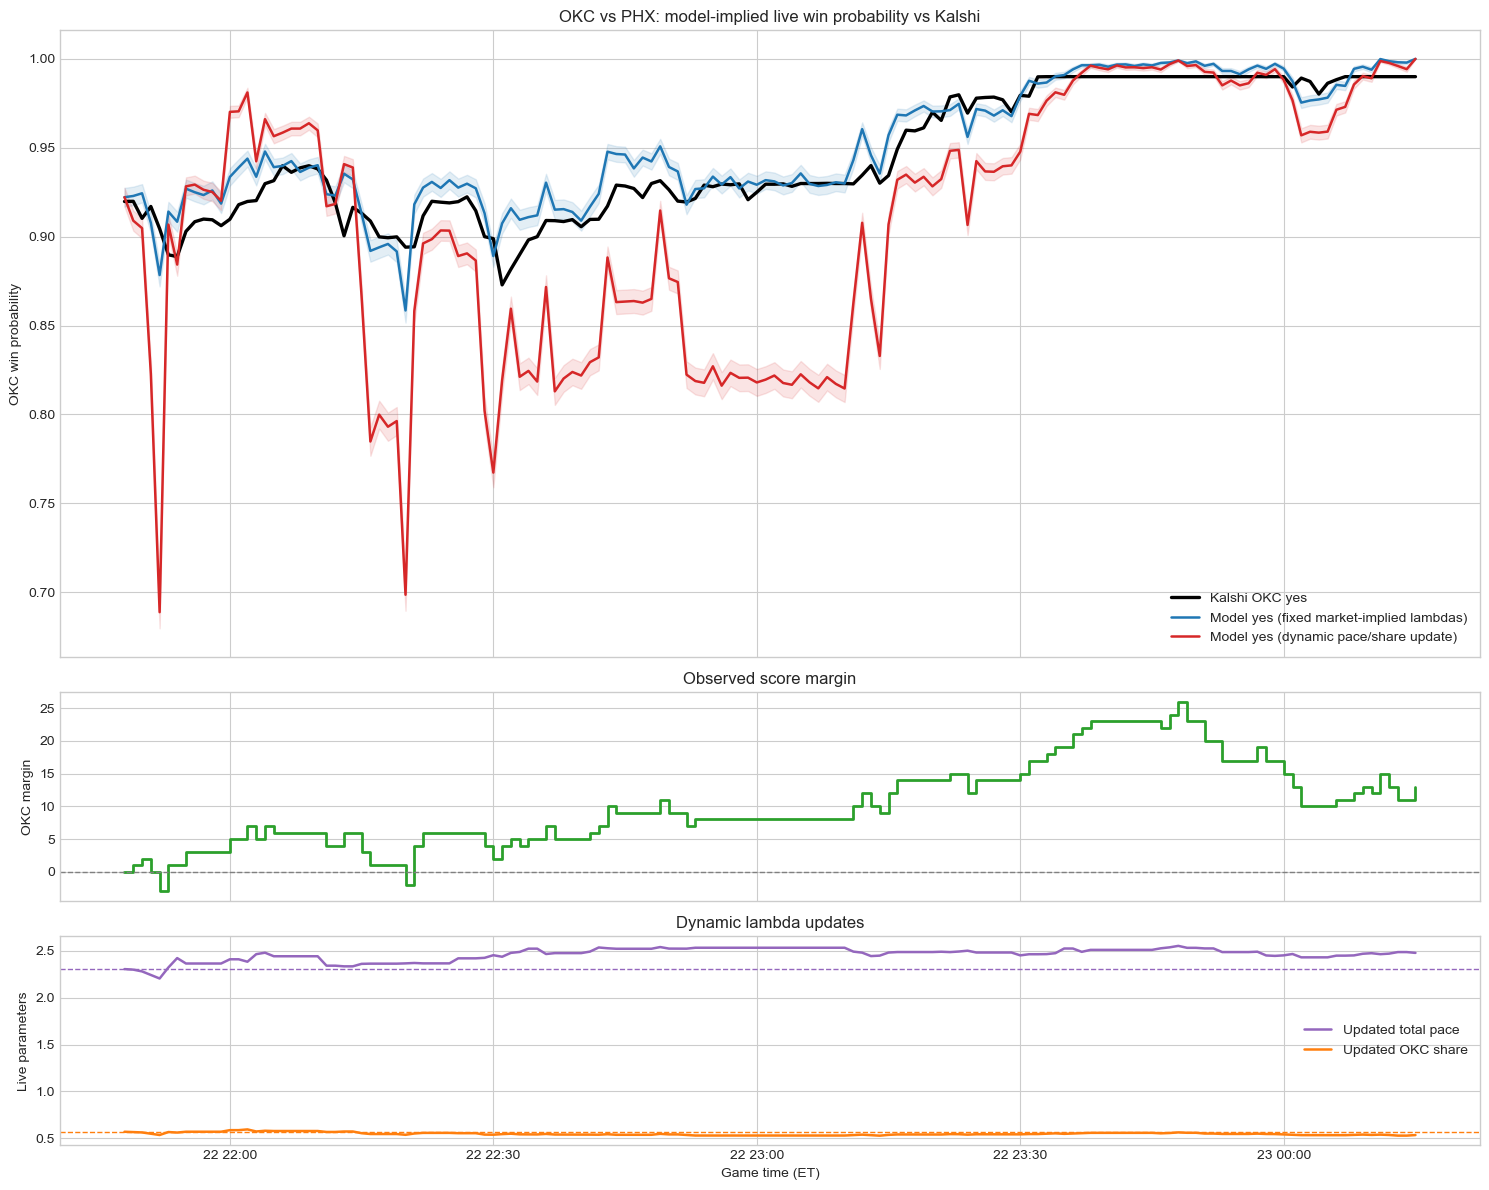

In [16]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 1]},
)

axes[0].plot(analysis["timestamp_et"], analysis["kalshi_yes_price"], label="Kalshi OKC yes", linewidth=2.4, color="black")
axes[0].plot(analysis["timestamp_et"], analysis["fixed_fair_yes"], label="Model yes (fixed market-implied lambdas)", linewidth=1.8, color="#1f77b4")
axes[0].fill_between(
    analysis["timestamp_et"],
    analysis["fixed_ci_low"],
    analysis["fixed_ci_high"],
    color="#1f77b4",
    alpha=0.12,
)
axes[0].plot(analysis["timestamp_et"], analysis["dynamic_fair_yes"], label="Model yes (dynamic pace/share update)", linewidth=1.8, color="#d62728")
axes[0].fill_between(
    analysis["timestamp_et"],
    analysis["dynamic_ci_low"],
    analysis["dynamic_ci_high"],
    color="#d62728",
    alpha=0.12,
)
axes[0].set_ylabel("OKC win probability")
axes[0].set_title("OKC vs PHX: model-implied live win probability vs Kalshi")
axes[0].legend(loc="best")

axes[1].step(analysis["timestamp_et"], analysis["current_margin"], where="post", color="#2ca02c", linewidth=2)
axes[1].axhline(0.0, color="gray", linewidth=1, linestyle="--")
axes[1].set_ylabel("OKC margin")
axes[1].set_title("Observed score margin")

axes[2].plot(analysis["timestamp_et"], analysis["dynamic_lambda_total_t"], label="Updated total pace", color="#9467bd", linewidth=1.8)
axes[2].plot(analysis["timestamp_et"], analysis["dynamic_strength_share_t"], label="Updated OKC share", color="#ff7f0e", linewidth=1.8)
axes[2].axhline(lambda_total_0, color="#9467bd", linestyle="--", linewidth=1)
axes[2].axhline(strength_share_a_0, color="#ff7f0e", linestyle="--", linewidth=1)
axes[2].set_ylabel("Live parameters")
axes[2].set_xlabel("Game time (ET)")
axes[2].set_title("Dynamic lambda updates")
axes[2].legend(loc="best")

plt.tight_layout()
plt.show()